In [1]:
!pip install adversarial-robustness-toolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.9 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import FastGradientMethod
from art.attacks.evasion import ProjectedGradientDescentPyTorch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
transform_mnist = transforms.Compose([
    transforms.ToTensor()
])

train_mnist = torchvision.datasets.MNIST(root='./data', train=True,
                                          download=True, transform=transform_mnist)

test_mnist = torchvision.datasets.MNIST(root='./data', train=False,
                                         download=True, transform=transform_mnist)

trainloader_mnist = torch.utils.data.DataLoader(train_mnist, batch_size=128, shuffle=True)
testloader_mnist = torch.utils.data.DataLoader(test_mnist, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 472kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


In [4]:
transform_cifar = transforms.Compose([
    transforms.ToTensor()
])

train_cifar = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=transform_cifar)

test_cifar = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=True, transform=transform_cifar)

trainloader_cifar = torch.utils.data.DataLoader(train_cifar, batch_size=128, shuffle=True)
testloader_cifar = torch.utils.data.DataLoader(test_cifar, batch_size=128, shuffle=False)

100%|██████████| 170M/170M [00:04<00:00, 40.2MB/s]


In [5]:
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes=10):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [6]:
class ConvNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(128*7*7 if in_channels==1 else 128*8*8, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))
        x = self.pool(F.relu(self.conv4(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [7]:
def train_model(model, trainloader, epochs=5):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        running_loss = 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1} Loss: {running_loss/len(trainloader)}")

    return model

In [8]:
mlp_mnist = MLP(28*28).to(device)
conv_mnist = ConvNet(in_channels=1).to(device)

mlp_mnist = train_model(mlp_mnist, trainloader_mnist)
conv_mnist = train_model(conv_mnist, trainloader_mnist)

Epoch 1 Loss: 0.36366667523026974
Epoch 2 Loss: 0.15637644862474154
Epoch 3 Loss: 0.10700784379771269
Epoch 4 Loss: 0.07981564189150517
Epoch 5 Loss: 0.0614433207713973
Epoch 1 Loss: 0.1590227618225729
Epoch 2 Loss: 0.040275725931711574
Epoch 3 Loss: 0.02601833009969757
Epoch 4 Loss: 0.019451048052092808
Epoch 5 Loss: 0.015058179645412373


In [9]:
mlp_cifar = MLP(32*32*3).to(device)
conv_cifar = ConvNet(in_channels=3).to(device)

mlp_cifar = train_model(mlp_cifar, trainloader_cifar)
conv_cifar = train_model(conv_cifar, trainloader_cifar)

Epoch 1 Loss: 1.868271149637754
Epoch 2 Loss: 1.7000373129344657
Epoch 3 Loss: 1.6305298664990593
Epoch 4 Loss: 1.5768130228037724
Epoch 5 Loss: 1.5355391093837025
Epoch 1 Loss: 1.572322096666107
Epoch 2 Loss: 1.1289832904515669
Epoch 3 Loss: 0.9159415534999974
Epoch 4 Loss: 0.7789340573351097
Epoch 5 Loss: 0.6720602712058046


In [10]:
vgg19 = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

for param in vgg19.features.parameters():
    param.requires_grad = False

vgg19.classifier[6] = nn.Linear(4096, 10)

vgg19 = vgg19.to(device)

vgg19 = train_model(vgg19, trainloader_cifar, epochs=1)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 72.7MB/s]


Epoch 1 Loss: 1.565502477119036


In [11]:
def get_art_classifier(model, input_shape):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    classifier = PyTorchClassifier(
        model=model,
        loss=criterion,
        optimizer=optimizer,
        input_shape=input_shape,
        nb_classes=10,
        device_type='gpu' if torch.cuda.is_available() else 'cpu'
    )
    return classifier

In [12]:
clf_mlp_mnist = get_art_classifier(mlp_mnist, (1,28,28))
clf_conv_mnist = get_art_classifier(conv_mnist, (1,28,28))
clf_mlp_cifar = get_art_classifier(mlp_cifar, (3,32,32))
clf_conv_cifar = get_art_classifier(conv_cifar, (3,32,32))
clf_vgg_cifar = get_art_classifier(vgg19, (3,32,32))

# Random Noise Attack

In [13]:
def random_noise_attack(classifier, x, eps):
    noise = np.random.uniform(-eps, eps, x.shape)
    x_adv = np.clip(x + noise, 0, 1)
    return x_adv

# FGSM Attack

In [14]:
def fgsm_attack(classifier, x, eps):
    attack = FastGradientMethod(estimator=classifier, eps=eps)
    x_adv = attack.generate(x=x)
    return x_adv

# PGD Attack

In [15]:
def pgd_linf_attack(classifier, x, eps, alpha):
    attack = ProjectedGradientDescentPyTorch(
        estimator=classifier,
        norm=np.inf,
        eps=eps,
        eps_step=alpha,
        max_iter=40
    )
    return attack.generate(x=x)

In [16]:
def targeted_pgd_attack(classifier, x, y_target, eps, alpha):
    attack = ProjectedGradientDescentPyTorch(
        estimator=classifier,
        norm=np.inf,
        eps=eps,
        eps_step=alpha,
        max_iter=40,
        targeted=True
    )
    return attack.generate(x=x, y=y_target)

In [17]:
def pgd_l2_attack(classifier, x, eps, alpha):
    attack = ProjectedGradientDescentPyTorch(
        estimator=classifier,
        norm=2,
        eps=eps,
        eps_step=alpha,
        max_iter=40
    )
    return attack.generate(x=x)

In [18]:
def misclassification_rate(classifier, x, y_true):
    preds = np.argmax(classifier.predict(x), axis=1)
    return np.mean(preds != y_true)

In [19]:
results = []

def log_result(dataset, model, method, norm, eps, alpha, total, mis_rate):
    results.append({
        "Dataset": dataset,
        "Model": model,
        "Method": method,
        "Norm": norm,
        "Epsilon": eps,
        "Alpha": alpha,
        "Total Samples": total,
        "Misclassification Rate": mis_rate
    })

In [20]:
df_results = pd.DataFrame(results)
df_results

""


In [21]:
def show_image(img, title=""):
    if img.shape[0] == 1:
        plt.imshow(img[0], cmap="gray")
    else:
        plt.imshow(np.transpose(img, (1,2,0)))
    plt.title(title)
    plt.axis("off")
    plt.show()


Running for MNIST - MLP


PGD - Batches:   0%|          | 0/16 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/16 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/16 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/16 [00:00<?, ?it/s]

...

PGD - Batches:   0%|          | 0/16 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/16 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/16 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/16 [00:00<?, ?it/s]


Displaying sample adversarial examples

MNIST - MLP


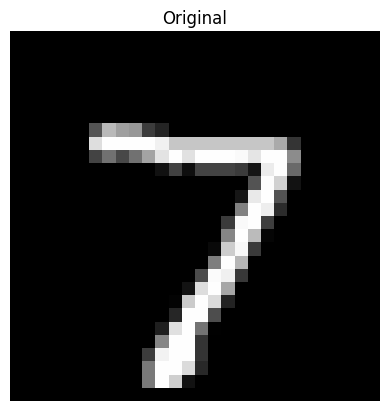

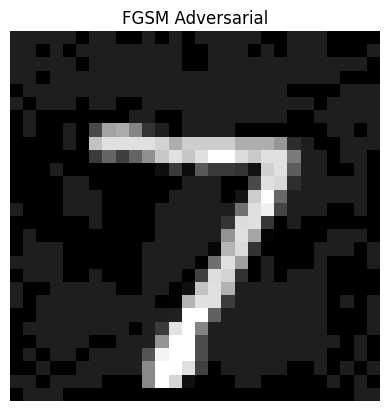


MNIST - ConvNet


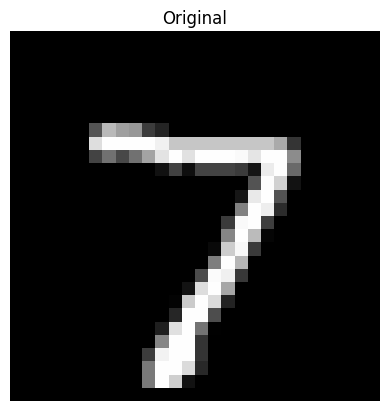

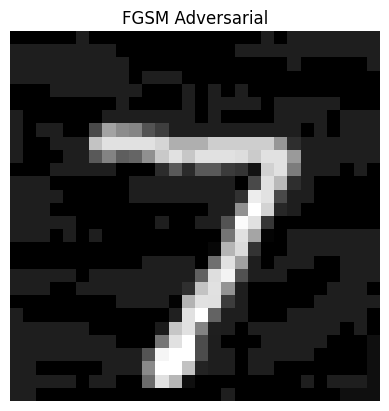

In [31]:

def get_numpy_data(loader, max_samples=500):
    images = []
    labels = []
    for x, y in loader:
        images.append(x.numpy())
        labels.append(y.numpy())
    x = np.concatenate(images).astype(np.float32)
    y = np.concatenate(labels)
    return x[:max_samples], y[:max_samples]

x_test_mnist, y_test_mnist = get_numpy_data(testloader_mnist)
x_test_cifar, y_test_cifar = get_numpy_data(testloader_cifar)

eps_values = np.random.uniform(0.001, 0.1, 5).astype(np.float32)
alpha_values = np.random.uniform(0.001, 0.1, 5).astype(np.float32)

experiments = [
    ("MNIST", "MLP", clf_mlp_mnist, x_test_mnist, y_test_mnist),
    ("MNIST", "ConvNet", clf_conv_mnist, x_test_mnist, y_test_mnist),
    ("CIFAR10", "MLP", clf_mlp_cifar, x_test_cifar, y_test_cifar),
    ("CIFAR10", "ConvNet", clf_conv_cifar, x_test_cifar, y_test_cifar),
    ("CIFAR10", "VGG19", clf_vgg_cifar, x_test_cifar, y_test_cifar),
]

results = []

def log_result(dataset, model, method, norm, eps, alpha, total, mis_rate):
    results.append({
        "Dataset": dataset,
        "Model": model,
        "Method": method,
        "Norm": norm,
        "Epsilon": float(eps),
        "Alpha": float(alpha) if alpha != "-" else "-",
        "Total Samples": total,
        "Misclassification Rate": float(mis_rate)
    })

for dataset, model_name, clf, x_data, y_data in experiments:

    print(f"\nRunning for {dataset} - {model_name}")

    for eps in eps_values:
        noise = np.random.uniform(-eps, eps, x_data.shape).astype(np.float32)
        x_adv = np.clip(x_data + noise, 0, 1).astype(np.float32)
        mis_rate = misclassification_rate(clf, x_adv, y_data)
        log_result(dataset, model_name, "Random Noise", "-", eps, "-", len(y_data), mis_rate)

    # FGSM
    for eps in eps_values:
        attack = FastGradientMethod(estimator=clf, eps=float(eps))
        x_adv = attack.generate(x=x_data).astype(np.float32)
        mis_rate = misclassification_rate(clf, x_adv, y_data)
        log_result(dataset, model_name, "FGSM", "Linf", eps, "-", len(y_data), mis_rate)

    # PGD Linf
    for eps, alpha in zip(eps_values, alpha_values):
        attack = ProjectedGradientDescentPyTorch(
            estimator=clf,
            norm=np.inf,
            eps=float(eps),
            eps_step=float(alpha),
            max_iter=40
        )
        x_adv = attack.generate(x=x_data).astype(np.float32)
        mis_rate = misclassification_rate(clf, x_adv, y_data)
        log_result(dataset, model_name, "PGD", "Linf", eps, alpha, len(y_data), mis_rate)

    # Targeted PGD Linf
    for eps, alpha in zip(eps_values, alpha_values):
        targets = np.random.randint(0, 10, len(y_data))
        attack = ProjectedGradientDescentPyTorch(
            estimator=clf,
            norm=np.inf,
            eps=float(eps),
            eps_step=float(alpha),
            max_iter=40,
            targeted=True
        )
        x_adv = attack.generate(x=x_data, y=targets).astype(np.float32)
        mis_rate = misclassification_rate(clf, x_adv, y_data)
        log_result(dataset, model_name, "Targeted PGD", "Linf", eps, alpha, len(y_data), mis_rate)

    # PGD L2
    for eps, alpha in zip(eps_values, alpha_values):
        attack = ProjectedGradientDescentPyTorch(
            estimator=clf,
            norm=2,
            eps=float(eps),
            eps_step=float(alpha),
            max_iter=40
        )
        x_adv = attack.generate(x=x_data).astype(np.float32)
        mis_rate = misclassification_rate(clf, x_adv, y_data)
        log_result(dataset, model_name, "PGD", "L2", eps, alpha, len(y_data), mis_rate)

print("\nDisplaying sample adversarial examples")

for dataset, model_name, clf, x_data, y_data in experiments[:2]:  # limited display
    sample = x_data[:1].astype(np.float32)
    eps = eps_values[0]

    attack = FastGradientMethod(estimator=clf, eps=float(eps))
    x_adv = attack.generate(x=sample).astype(np.float32)

    print(f"\n{dataset} - {model_name}")
    show_image(sample[0], "Original")
    show_image(x_adv[0], "FGSM Adversarial")


# Summary Table

In [27]:
summary = df_results.groupby(
    ["Dataset","Model","Method","Norm"]
)["Misclassification Rate"].mean().reset_index()

summary = summary.sort_values(by=["Dataset","Model","Method","Norm"])

display(summary)

,Dataset,Model,Method,Norm,Misclassification Rate
0,CIFAR10,ConvNet,FGSM,Linf,0.8696
1,CIFAR10,ConvNet,PGD,L2,0.3108
2,CIFAR10,ConvNet,PGD,Linf,0.8772
3,CIFAR10,ConvNet,Random Noise,-,0.3172
4,CIFAR10,ConvNet,Targeted PGD,Linf,0.8096
5,CIFAR10,MLP,FGSM,Linf,0.8008
6,CIFAR10,MLP,PGD,L2,0.5956
7,CIFAR10,MLP,PGD,Linf,0.8296
8,CIFAR10,MLP,Random Noise,-,0.5968
9,CIFAR10,MLP,Targeted PGD,Linf,0.7912



CIFAR10 - VGG19


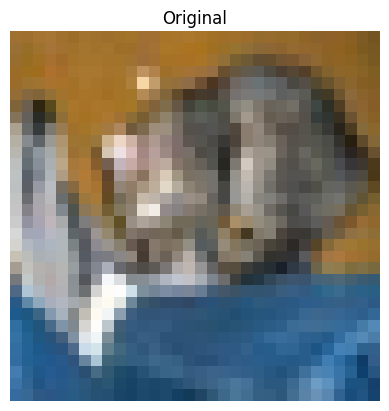

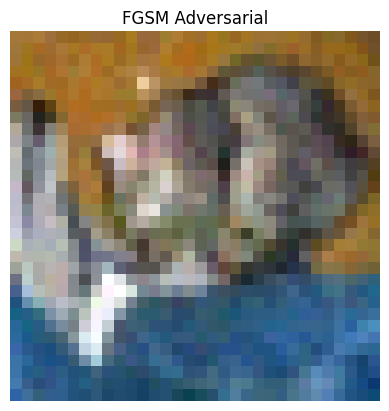

In [26]:
for dataset, model_name, clf, x_data, y_data in experiments:
    if dataset == "CIFAR10" and model_name == "VGG19":
        sample = x_data[:1].astype(np.float32)
        eps = eps_values[0]
        attack = FastGradientMethod(estimator=clf, eps=float(eps))
        x_adv = attack.generate(x=sample).astype(np.float32)

        print(f"\n{dataset} - {model_name}")
        show_image(sample[0], "Original")
        show_image(x_adv[0], "FGSM Adversarial")

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

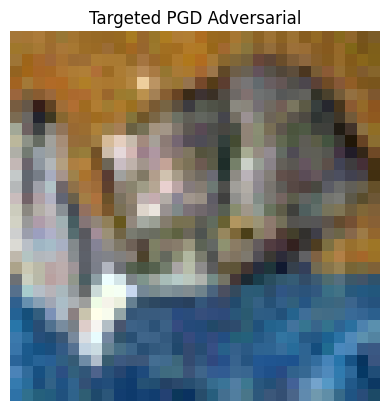

In [29]:
targets = np.random.randint(0,10,len(sample))
attack = ProjectedGradientDescentPyTorch(
    estimator=clf,
    norm=np.inf,
    eps=float(eps_values[0]),
    eps_step=float(alpha_values[0]),
    max_iter=40,
    targeted=True
)
x_adv = attack.generate(x=sample, y=targets).astype(np.float32)
show_image(x_adv[0], "Targeted PGD Adversarial")

PGD - Batches:   0%|          | 0/1 [00:00<?, ?it/s]

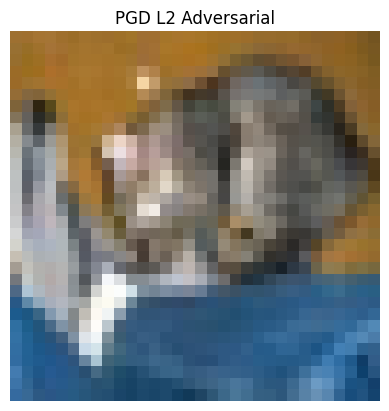

In [30]:
attack = ProjectedGradientDescentPyTorch(
    estimator=clf,
    norm=2,
    eps=float(eps_values[0]),
    eps_step=float(alpha_values[0]),
    max_iter=40
)
x_adv = attack.generate(x=sample).astype(np.float32)
show_image(x_adv[0], "PGD L2 Adversarial")

# Results and Observations

The experimental results clearly demonstrate that gradient-based adversarial attacks significantly degrade model performance across both MNIST and CIFAR-10 datasets. ℓ∞-based PGD achieved the highest misclassification rates overall, particularly on CIFAR-10 models, where VGG19 reached a rate of 0.9100 and ConvNet reached 0.8772, highlighting the strong effectiveness of iterative bounded perturbations. ℓ2 PGD was generally less effective than ℓ∞ PGD, especially on MNIST models where the misclassification rate remained very low (e.g., 0.0132 for ConvNet), showing the impact of norm choice on attack strength. MNIST ConvNet exhibited relatively higher robustness compared to MNIST MLP, whereas CIFAR-10 models were significantly more vulnerable across all attacks due to higher input dimensionality and complexity. Random noise produced comparatively lower misclassification rates, confirming that gradient-guided perturbations are substantially more powerful than unguided noise. Overall, the results illustrate that deeper and higher-capacity models such as VGG19 are highly susceptible to adversarial perturbations, emphasizing the necessity of adversarial defense mechanisms for real-world deployment.

PGD attacks achieve higher misclassification rates than FGSM, indicating stronger iterative optimization.

Increasing epsilon generally increases the misclassification rate across all models and datasets.

CIFAR-10 models exhibit higher vulnerability compared to MNIST due to higher dimensional input and model complexity.

Targeted PGD achieves controlled misclassification but often has lower success rate than untargeted PGD.

ℓ∞ attacks generally show stronger effect compared to ℓ2 attacks at similar epsilon values.

VGG19 shows high susceptibility under FGSM and PGD due to its deep architecture.